# Volatility Forecasting: ARCH vs. GARCH vs. EWMA

The goal here is to fit three different volatility models on JPM daily returns and see how well each one can predict volatility a few days out. I'm using 3 years of daily data (2022-2024) to train the models and then comparing their 5-day-ahead forecasts against what actually happened in early January 2025.

The three models I'm comparing:
- **ARCH(1)** - variance only depends on the previous day's squared return
- **GARCH(1,1)** - adds a persistence term so variance also depends on yesterday's variance
- **EWMA (λ=0.94)** - exponentially weighted moving average, basically a simplified version of GARCH with no intercept. This is the RiskMetrics standard.

## 1. Setup & Data

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from arch import arch_model

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

### Download JPM prices and compute daily % returns

Pulling 3 years of daily close prices and converting to percentage returns. Using the same dataset for all three models so the comparison is fair.

In [2]:
symbol = 'JPM'
df = yf.download(symbol, start='2022-01-01', end='2025-01-01')

df['returns'] = df['Close'].pct_change() * 100  # daily % return
returns = df['returns'].dropna()

print(f"Observations: {len(returns)}")
print(f"Mean daily return: {returns.mean():.4f}%")
print(f"Std dev (daily):   {returns.std():.4f}%")
returns.tail()

C:\Users\arora\AppData\Local\Temp\ipykernel_28364\3447271869.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start='2022-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

Observations: 752
Mean daily return: 0.0759%
Std dev (daily):   1.5743%


Date
2024-12-24    1.644365
2024-12-26    0.342529
2024-12-27   -0.810234
2024-12-30   -0.767080
2024-12-31    0.162956
Name: returns, dtype: float64

### Returns distribution

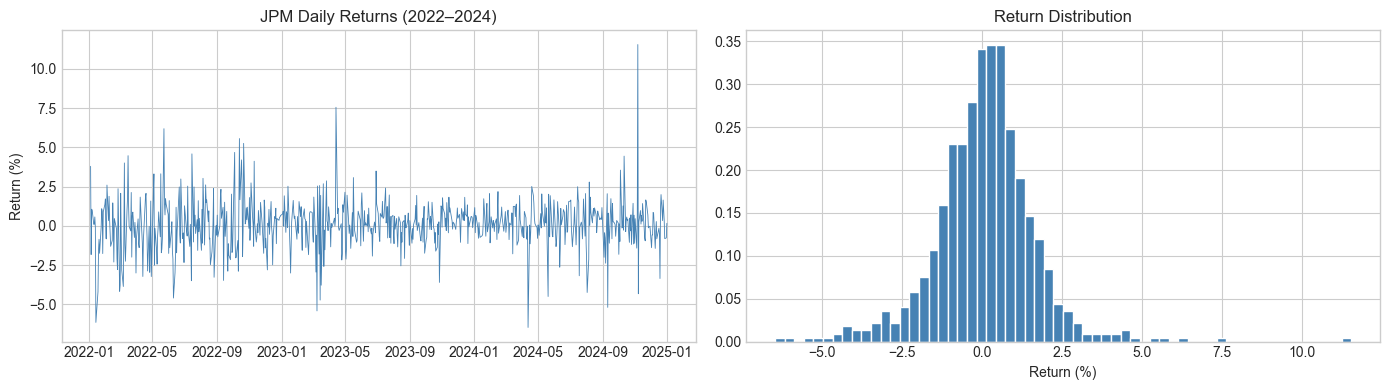

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(returns.index, returns.values, linewidth=0.6, color='steelblue')
axes[0].set_title('JPM Daily Returns (2022–2024)')
axes[0].set_ylabel('Return (%)')

axes[1].hist(returns.values, bins=60, edgecolor='white', color='steelblue', density=True)
axes[1].set_title('Return Distribution')
axes[1].set_xlabel('Return (%)')

plt.tight_layout()
plt.show()

Looking at the time series plot, you can see periods where the returns are jumping around a lot followed by calmer stretches. That's volatility clustering, and it's the main reason these models exist - if volatility were constant, we wouldn't need any of this. The histogram also shows fatter tails than you'd expect from a normal distribution.

## 2. Realized Volatility (Benchmark)

Before fitting anything, I need to figure out what actually happened so I have something to compare my forecasts against. I'm pulling the first 5 trading days of January 2025 and computing the realized daily volatility (just the standard deviation of the daily returns over that window).

Everything in this notebook is compared in daily vol terms to keep things consistent across models.

In [4]:
# First 5 trading days of Jan 2025
real_df = yf.download('JPM', start='2024-12-31', end='2025-01-09')
real_df['returns'] = real_df['Close'].pct_change() * 100
real_df = real_df.dropna()

# Keep exactly 5 trading days
real_df = real_df.head(5)

# Realized daily vol = sample std of the 5 daily returns
realized_vol = real_df['returns'].std()

print(f"Trading days used: {len(real_df)}")
print(f"Realized daily vol: {realized_vol:.4f}%")
print()
print(real_df[['Close', 'returns']])

C:\Users\arora\AppData\Local\Temp\ipykernel_28364\3481393752.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  real_df = yf.download('JPM', start='2024-12-31', end='2025-01-09')
[*********************100%***********************]  1 of 1 completed

Trading days used: 5
Realized daily vol: 0.7567%

Price            Close   returns
Ticker             JPM          
Date                            
2025-01-02  233.969391  0.120974
2025-01-03  237.166977  1.366669
2025-01-06  236.010681 -0.487545
2025-01-07  238.284058  0.963252
2025-01-08  238.244873 -0.016444


## 3. ARCH(1) Model

The ARCH(1) model estimates today's variance as:

$$\sigma_t^2 = \omega + \alpha_1 \, \varepsilon_{t-1}^2$$

So it only looks at yesterday's squared return to figure out today's variance. It has no way to "remember" what variance was like before that, which means it can't really capture the slow-moving persistence you see in real volatility.

In [5]:
arch_model_fit = arch_model(returns, vol='ARCH', p=1, mean='Constant')
arch_results = arch_model_fit.fit(disp='off')
print(arch_results.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -1400.95
Distribution:                  Normal   AIC:                           2807.90
Method:            Maximum Likelihood   BIC:                           2821.76
                                        No. Observations:                  752
Date:                Fri, Feb 27 2026   Df Residuals:                      751
Time:                        05:24:46   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0978  5.518e-02      1.772  7.645e-02 [-1.03

Looking at the fitted parameters:
- **omega** is the baseline variance. Since ARCH has no persistence term, omega has to be pretty large on its own to account for the average variance level.
- **alpha[1]** controls how much the model reacts to yesterday's squared return. Higher alpha means it swings harder after big moves but also mean-reverts faster.

In [6]:
# 5-day-ahead forecast
arch_forecast = arch_results.forecast(horizon=5)
arch_pred_var = arch_forecast.variance.iloc[-1].values  # last row = forecast from end of sample

arch_pred_vol = np.sqrt(arch_pred_var)
arch_avg_vol = arch_pred_vol.mean()

print("ARCH predicted daily vol per day:", [f"{v:.4f}" for v in arch_pred_vol])
print(f"ARCH avg predicted daily vol: {arch_avg_vol:.4f}%")

ARCH predicted daily vol per day: ['1.4793', '1.5670', '1.5774', '1.5787', '1.5789']
ARCH avg predicted daily vol: 1.5563%


## 4. GARCH(1,1) Model

GARCH(1,1) adds a persistence term to ARCH:

$$\sigma_t^2 = \omega + \alpha_1 \, \varepsilon_{t-1}^2 + \beta_1 \, \sigma_{t-1}^2$$

The β term is what makes this different. It lets today's variance carry over most of yesterday's variance, so the model can capture the fact that when volatility is high, it tends to stay high for a while before coming back down. This is the most commonly used volatility model in practice.

In [7]:
garch_model_fit = arch_model(returns, vol='GARCH', p=1, q=1, mean='Constant')
garch_results = garch_model_fit.fit(disp='off')
print(garch_results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1387.47
Distribution:                  Normal   AIC:                           2782.94
Method:            Maximum Likelihood   BIC:                           2801.43
                                        No. Observations:                  752
Date:                Fri, Feb 27 2026   Df Residuals:                      751
Time:                        05:24:46   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1146  5.754e-02      1.991  4.648e-02 [1.786e-0

Looking at the parameters:
- **alpha[1]** is much smaller here than in the ARCH model. The model doesn't need to react as hard to individual shocks because it has the persistence term doing most of the work.
- **beta[1]** is close to 1, meaning yesterday's variance carries over almost entirely into today. This is typical for GARCH on equity returns.
- **alpha + beta ≈ 1** tells us the process is close to integrated (IGARCH), meaning shocks to variance are basically permanent. That's why the GARCH forecasts are so stable across the 5-day horizon compared to ARCH.

In [8]:
# 5-day-ahead forecast
garch_forecast = garch_results.forecast(horizon=5)
garch_pred_var = garch_forecast.variance.iloc[-1].values

garch_pred_vol = np.sqrt(garch_pred_var)
garch_avg_vol = garch_pred_vol.mean()

print("GARCH predicted daily vol per day:", [f"{v:.4f}" for v in garch_pred_vol])
print(f"GARCH avg predicted daily vol: {garch_avg_vol:.4f}%")

GARCH predicted daily vol per day: ['1.6235', '1.6223', '1.6210', '1.6198', '1.6186']
GARCH avg predicted daily vol: 1.6210%


## 5. EWMA Model (λ = 0.94)

EWMA is really just a special case of GARCH where you set ω = 0 and force α + β = 1:

$$\sigma_t^2 = \lambda \, \sigma_{t-1}^2 + (1 - \lambda) \, r_{t-1}^2$$

With λ = 0.94, each day's variance is 94% of yesterday's variance plus 6% of yesterday's squared return. Since there's no mean-reversion term (ω = 0), the forecast is completely flat. The predicted daily vol for tomorrow is the same as for 5 days from now. So for EWMA, there's really only one forecast number.

In [9]:
lam = 0.94

# Build the EWMA variance series iteratively
ewma_var = np.zeros(len(returns))
ewma_var[0] = returns.iloc[0] ** 2  # initialize with first squared return

for t in range(1, len(returns)):
    ewma_var[t] = lam * ewma_var[t - 1] + (1 - lam) * (returns.iloc[t - 1] ** 2)

ewma_daily_vol = np.sqrt(ewma_var[-1])  # latest daily vol estimate (flat forecast)

print(f"EWMA predicted daily vol: {ewma_daily_vol:.4f}%")

EWMA predicted daily vol: 1.5301%


## 6. Model Comparison

Comparing all three models side by side against realized daily vol. For ARCH and GARCH I'm taking the mean of the 5 daily vol forecasts, and for EWMA it's just the single daily vol estimate since the forecast doesn't change.

In [10]:
results_table = pd.DataFrame({
    'Model': ['ARCH(1)', 'GARCH(1,1)', 'EWMA (λ=0.94)', 'Realized'],
    'Avg Daily Vol (%)': [
        arch_avg_vol,
        garch_avg_vol,
        ewma_daily_vol,
        realized_vol
    ]
})

# Calculate error vs realized
results_table['Error vs Realized (%)'] = (
    (results_table['Avg Daily Vol (%)'] - realized_vol) / realized_vol * 100
).round(2)

# Mark realized row as NaN for error
results_table.loc[results_table['Model'] == 'Realized', 'Error vs Realized (%)'] = None

results_table['Avg Daily Vol (%)'] = results_table['Avg Daily Vol (%)'].round(4)

print(results_table.to_string(index=False))

        Model  Avg Daily Vol (%)  Error vs Realized (%)
      ARCH(1)             1.5563                 105.67
   GARCH(1,1)             1.6210                 114.24
EWMA (λ=0.94)             1.5301                 102.21
     Realized             0.7567                    NaN


### Visualization

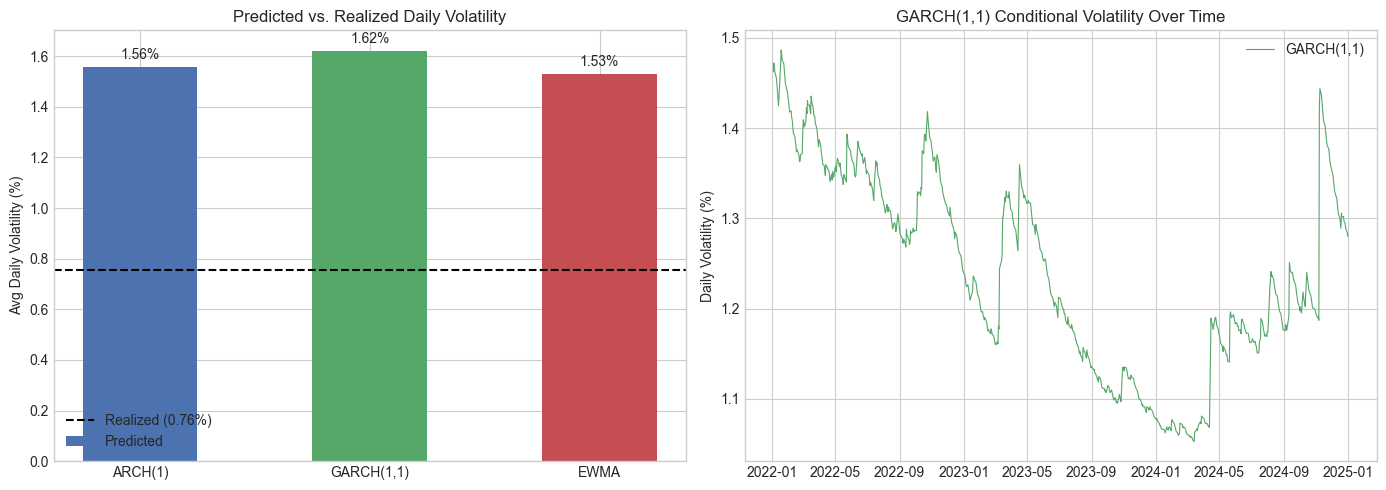

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart: predicted vs realized ---
models = ['ARCH(1)', 'GARCH(1,1)', 'EWMA']
predicted = [arch_avg_vol, garch_avg_vol, ewma_daily_vol]
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = axes[0].bar(models, predicted, color=colors, width=0.5, label='Predicted')
axes[0].axhline(y=realized_vol, color='black', linestyle='--', linewidth=1.5, label=f'Realized ({realized_vol:.2f}%)')
axes[0].set_ylabel('Avg Daily Volatility (%)')
axes[0].set_title('Predicted vs. Realized Daily Volatility')
axes[0].legend()

# Annotate bars
for bar, val in zip(bars, predicted):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

# --- Conditional variance over time ---
garch_cond_vol = np.sqrt(garch_results.conditional_volatility)
axes[1].plot(returns.index, garch_cond_vol, linewidth=0.8, color='#55A868', label='GARCH(1,1)')
axes[1].set_title('GARCH(1,1) Conditional Volatility Over Time')
axes[1].set_ylabel('Daily Volatility (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Takeaways

All three models overpredicted by roughly 2x here. The realized daily vol over those 5 January days was only about 0.76%, while the models were all forecasting around 1.5-1.6%. That's a big miss, but it makes sense when you consider that those 5 days were unusually calm compared to the 3-year training sample (which had an average daily vol of ~1.57%). Basically the models are predicting something close to the long-run average, and this particular week just happened to be quiet.

The bigger issue is that 5 trading days is a really small sample to compute "realized" volatility from. The benchmark itself is noisy. If I wanted to do this more rigorously, I'd run a rolling backtest - forecast every month for a couple years and then look at the average error across all those windows. That would give much more reliable error numbers.

Between the three models, GARCH gives the most stable day-to-day forecasts since the β term smooths things out. ARCH converges to its unconditional variance within a few steps and loses track of the current regime. EWMA is the simplest but its flat forecast means it can't really differentiate between short and longer horizons.

One thing all three models miss is asymmetry - they treat positive and negative returns the same way. In reality, negative returns tend to spike volatility more than positive returns of the same size (leverage effect). EGARCH or GJR-GARCH would handle that, which could be worth exploring as a next step.